In [1]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import pygame
import os
import pickle
import time

RENDER_FPS = 30
CELL_SIZE = 50
COLORS = {
    'bg': (30, 30, 35), 'wall': (50, 55, 65),
    'boost': (100, 140, 255), 'courier': (255, 215, 0),
    'courier_boost': (255, 80, 80), 'goal': (0, 200, 83),
    'text': (255, 255, 255), 'ui_bg': (20, 20, 25)
}

LEARNING_RATE = 0.15
GAMMA = 0.95
EPSILON_START = 1.0
EPSILON_MIN = 0.02
EPSILON_DECAY = 0.9997
MAX_STEPS = 150

In [2]:
class CourierEnv(gym.Env):
    
    metadata = {'render_modes': ['human']}

    def __init__(self, render_mode=None):
        super().__init__()
        self.render_mode = render_mode
        
        self.grid_map = [
            [1,1,1,1,1,1,1,1,1,1],
            [1,0,0,0,1,0,2,0,0,1],
            [1,1,1,0,1,0,1,1,2,1],
            [1,0,0,0,0,2,1,0,0,1],
            [1,0,1,1,1,1,1,0,1,1],
            [1,2,0,0,1,0,0,0,0,1],
            [1,1,1,0,1,2,1,1,0,1],
            [1,0,0,0,0,0,1,3,0,1],
            [1,0,1,1,1,1,1,1,0,1],
            [1,1,1,1,1,1,1,1,1,1]
        ]
        self.rows, self.cols = len(self.grid_map), len(self.grid_map[0])
        
        self.goal_pos = None
        self.free_positions, self.boost_positions = [], []
        for r in range(self.rows):
            for c in range(self.cols):
                cell = self.grid_map[r][c]
                if cell == 3: self.goal_pos = (c, r)
                elif cell in (0, 2): self.free_positions.append((c, r))
                if cell == 2: self.boost_positions.append((c, r))
                
        self.action_space = spaces.Discrete(5)
        self.observation_space = spaces.Discrete(self.rows * self.cols * 4 * 2)
        
        self.courier_pos = self.courier_angle = None
        self.boost_available = self.boost_active = False
        self.steps_taken = 0
        
        self.window = self.clock = self.font = None

    def _get_state_index(self):
        x, y = self.courier_pos
        boost_flag = 1 if self.boost_available else 0
        return int(x + y * self.cols + 
                   self.courier_angle * self.cols * self.rows + 
                   boost_flag * self.cols * self.rows * 4)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        start = self.free_positions[self.np_random.integers(len(self.free_positions))]
        self.courier_pos = list(start)
        self.courier_angle = self.np_random.integers(4)
        self.boost_available = True
        self.boost_active = False
        self.steps_taken = 0
        return self._get_state_index(), {}

    def _can_enter(self, x, y, with_boost=False):
        if not (0 <= x < self.cols and 0 <= y < self.rows):
            return False
        cell = self.grid_map[y][x]
        return cell != 1 and (cell != 2 or with_boost)

    def step(self, action):
        self.steps_taken += 1
        reward = -0.5
        old_dist = abs(self.goal_pos[0] - self.courier_pos[0]) + abs(self.goal_pos[1] - self.courier_pos[1])
        dx, dy, moved, used_boost = 0, 0, False, False
        dirs = [(1,0), (0,1), (-1,0), (0,-1)]
        
        if action == 0: dx, dy = dirs[self.courier_angle]; moved = True
        elif action == 1: dx, dy = [-d for d in dirs[self.courier_angle]]; moved = True
        elif action == 2: self.courier_angle = (self.courier_angle + 1) % 4; reward -= 0.2
        elif action == 3: self.courier_angle = (self.courier_angle - 1) % 4; reward -= 0.2
        elif action == 4:
            if self.boost_available:
                self.boost_active = self.boost_available = False
                used_boost = True
                dx, dy = dirs[self.courier_angle]; moved = True
                reward -= 1.0
            else: reward -= 3.0
            
        if moved:
            nx, ny = self.courier_pos[0] + dx, self.courier_pos[1] + dy
            if self._can_enter(nx, ny, with_boost=(self.boost_active or used_boost)):
                self.courier_pos = [int(nx), int(ny)]
                if used_boost and self.grid_map[int(ny)][int(nx)] == 2:
                    reward += 3.0
            else:
                reward -= 8.0
                self.boost_active = False
                
        if not self.boost_available and self.steps_taken % 3 == 0:
            self.boost_available = True
        self.boost_active = False
        
        new_dist = abs(self.goal_pos[0] - self.courier_pos[0]) + abs(self.goal_pos[1] - self.courier_pos[1])
        if new_dist < old_dist: reward += 8.0
        elif new_dist > old_dist: reward -= 3.0
        
        terminated = tuple(self.courier_pos) == self.goal_pos
        if terminated: reward += 120.0
        truncated = self.steps_taken >= MAX_STEPS
        
        return self._get_state_index(), reward, terminated, truncated, {}

    def render(self):
        if self.render_mode is None:
            return
        if self.window is None:
            pygame.init()
            self.window = pygame.display.set_mode((self.cols * CELL_SIZE, self.rows * CELL_SIZE + 80))
            pygame.display.set_caption("Courier RL Environment")
            self.clock = pygame.time.Clock()
            self.font = pygame.font.SysFont("Consolas", 14)
        
        self.window.fill(COLORS['bg'])
        
        for r in range(self.rows):
            for c in range(self.cols):
                x, y = c * CELL_SIZE, r * CELL_SIZE
                cell = self.grid_map[r][c]
                if cell == 1:
                    pygame.draw.rect(self.window, COLORS['wall'], (x, y, CELL_SIZE, CELL_SIZE))
                elif cell == 2:
                    pygame.draw.rect(self.window, (25, 25, 40), (x, y, CELL_SIZE, CELL_SIZE))
                    pygame.draw.rect(self.window, COLORS['boost'], (x+3, y+3, CELL_SIZE-6, CELL_SIZE-6), 2)
                    cx, cy = x + CELL_SIZE//2, y + CELL_SIZE//2
                    pygame.draw.polygon(self.window, COLORS['boost'], [(cx, cy-8), (cx-6, cy+6), (cx+6, cy+6)])
                elif cell == 3:
                    pygame.draw.circle(self.window, COLORS['goal'], (x + CELL_SIZE//2, y + CELL_SIZE//2), CELL_SIZE//3)
                    
        ax, ay = self.courier_pos[0]*CELL_SIZE + CELL_SIZE//2, self.courier_pos[1]*CELL_SIZE + CELL_SIZE//2
        dirs = [(1,0), (0,1), (-1,0), (0,-1)]
        dx, dy = dirs[self.courier_angle]
        color = COLORS['courier_boost'] if self.boost_active else COLORS['courier']
        
        pygame.draw.circle(self.window, color, (ax, ay), 11)
        pygame.draw.circle(self.window, (30, 30, 35), (ax, ay), 9)
        pygame.draw.line(self.window, color, (ax, ay), (ax + dx*18, ay + dy*18), 5)
        
        ui_y = self.rows * CELL_SIZE + 5
        pygame.draw.rect(self.window, COLORS['ui_bg'], (5, ui_y, self.cols*CELL_SIZE-10, 70), border_radius=5)
        status = "BOOST: AVAILABLE" if self.boost_available else "BOOST: RECHARGING"
        status_color = COLORS['goal'] if self.boost_available else (150, 150, 150)
        self.window.blit(self.font.render(status, True, status_color), (15, ui_y + 8))
        dirs_ru = ['EAST', 'SOUTH', 'WEST', 'NORTH']
        self.window.blit(self.font.render(f"Steps: {self.steps_taken}/{MAX_STEPS} | Dir: {dirs_ru[self.courier_angle]}", True, COLORS['text']), (15, ui_y + 32))
        
        pygame.display.flip()
        self.clock.tick(RENDER_FPS)

    def close(self):
        if self.window is not None:
            pygame.quit()
            self.window = self.clock = self.font = None

In [3]:
class QLearningAgent:
    def __init__(self, state_size, action_size, lr=LEARNING_RATE, gamma=GAMMA, epsilon=EPSILON_START):
        self.q_table = np.zeros((state_size, action_size))
        self.action_size = action_size
        self.lr = lr
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = EPSILON_MIN
        self.epsilon_decay = EPSILON_DECAY

    def get_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.action_size)
        return np.argmax(self.q_table[state])

    def learn(self, state, action, reward, next_state, done):
        current_q = self.q_table[state][action]
        max_next_q = 0 if done else np.max(self.q_table[next_state])
        new_q = current_q + self.lr * (reward + self.gamma * max_next_q - current_q)
        self.q_table[state][action] = new_q

    def update_epsilon(self):
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

In [4]:
def train_courier(episodes=3000, save_path='courier_model.pkl'):
    env = CourierEnv(render_mode=None)
    agent = QLearningAgent(env.observation_space.n, env.action_space.n)
    
    history = {'rewards': [], 'successes': [], 'steps': []}
    
    for e in range(episodes):
        state, _ = env.reset()
        total_r, steps = 0, 0
        done = trunc = False
        
        while not (done or trunc):
            action = agent.get_action(state)
            s_next, r, done, trunc, _ = env.step(action)
            agent.learn(state, action, r, s_next, done or trunc)
            state, total_r, steps = s_next, total_r + r, steps + 1
            
        agent.update_epsilon()
        history['rewards'].append(total_r)
        history['successes'].append(1 if (done and total_r > 100) else 0)
        history['steps'].append(steps)
        
        if (e + 1) % 500 == 0:
            avg_r = np.mean(history['rewards'][-100:])
            succ = sum(history['successes'][-100:])
            print(f"Episode {e+1}/{episodes} | Avg Reward: {avg_r:.2f} | Successes: {succ}/100")
            
    env.close()
    
    os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
    with open(save_path, 'wb') as f:
        pickle.dump(agent.q_table, f)
    
    return agent, {k: np.array(v) for k, v in history.items()}

In [5]:
def plot_results(history, save_path='training_results.png'):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle('Training Metrics', fontsize=14, fontweight='bold')
    
    ax = axes[0, 0]
    ax.plot(history['rewards'], alpha=0.2, color='gray')
    ma = np.convolve(history['rewards'], np.ones(100)/100, mode='valid')
    ax.plot(range(99, len(history['rewards'])), ma, color='blue', linewidth=2)
    ax.set_title('Episode Reward'); ax.set_xlabel('Episode'); ax.set_ylabel('Reward')
    ax.grid(alpha=0.3)
    
    ax = axes[0, 1]
    success_rate = np.convolve(history['successes'], np.ones(100)/100, mode='valid')
    ax.plot(range(99, len(history['successes'])), success_rate * 100, color='green', linewidth=2)
    ax.set_title('Success Rate'); ax.set_xlabel('Episode'); ax.set_ylabel('%')
    ax.set_ylim(0, 100); ax.grid(alpha=0.3)
    
    ax = axes[1, 0]
    ma_steps = np.convolve(history['steps'], np.ones(50)/50, mode='valid')
    ax.plot(range(49, len(history['steps'])), ma_steps, color='orange', linewidth=2)
    ax.set_title('Avg Episode Length'); ax.set_xlabel('Episode'); ax.set_ylabel('Steps')
    ax.grid(alpha=0.3)
    
    ax = axes[1, 1]
    ax.text(0.5, 0.5, f"Final Avg Reward: {np.mean(history['rewards'][-100:]):.2f}\nTotal Episodes: {len(history['rewards'])}", 
            ha='center', va='center', fontsize=12)
    ax.set_title('Summary')
    ax.axis('off')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

In [6]:
def test_agent(start_pos=None, angle=0, model_path='courier_model.pkl', delay=0.1):
    env = CourierEnv(render_mode='human')
    agent = QLearningAgent(env.observation_space.n, env.action_space.n, epsilon=0.0)
    
    if model_path and os.path.exists(model_path):
        with open(model_path, 'rb') as f:
            agent.q_table = pickle.load(f)
        
    if start_pos:
        env.courier_pos = list(start_pos)
        env.courier_angle = angle
        env.boost_available = True
        env.steps_taken = 0
        state = env._get_state_index()
    else:
        state, _ = env.reset()
        
    done, trunc = False, False
    path = [tuple(env.courier_pos)]
    
    while not (done or trunc):
        action = agent.get_action(state)
        state, reward, done, trunc, _ = env.step(action)
        path.append(tuple(env.courier_pos))
        env.render()
        pygame.event.pump()
        time.sleep(delay)
        
    print(f"Test finished. Reward: {reward:.1f}, Steps: {env.steps_taken}")
    
    for _ in range(60):
        env.render()
        pygame.event.pump()
        time.sleep(0.05)
    env.close()
    return path

In [7]:

def demo_agent(start_pos=None, angle=0, model_path='models/courier_boost.pkl', speed=0.1):

    env = CourierEnv(render_mode='human')
    agent = QLearningAgent(env.observation_space.n, env.action_space.n, epsilon=0.0)
    
    if os.path.exists(model_path):
        with open(model_path, 'rb') as f: agent.q_table = pickle.load(f)
    else:
        env.close(); return
    
    if start_pos:
        env.courier_pos = list(start_pos); env.courier_angle = angle
        env.boost_available = True; env.steps_taken = 0
        state = env._get_state_index()
    else:
        state, _ = env.reset()
    
    done = trunc = False
    path = [tuple(env.courier_pos)]
    
    while not (done or trunc):
        action = agent.get_action(state)
        
        state, r, done, trunc, _ = env.step(action)
        path.append(tuple(env.courier_pos))
        env.render()
        time.sleep(speed)
        
        if done and r > 100:
            time.sleep(2.5)
    
    if not done:
        time.sleep(1.5)
    
    env.close()
    return path

In [8]:
agent, history = train_courier(episodes=3000)

Episode 500/3000 | Avg Reward: -190.62 | Successes: 7/100
Episode 1000/3000 | Avg Reward: -1.58 | Successes: 26/100
Episode 1500/3000 | Avg Reward: 97.11 | Successes: 58/100
Episode 2000/3000 | Avg Reward: 123.01 | Successes: 80/100
Episode 2500/3000 | Avg Reward: 139.42 | Successes: 97/100
Episode 3000/3000 | Avg Reward: 147.98 | Successes: 97/100


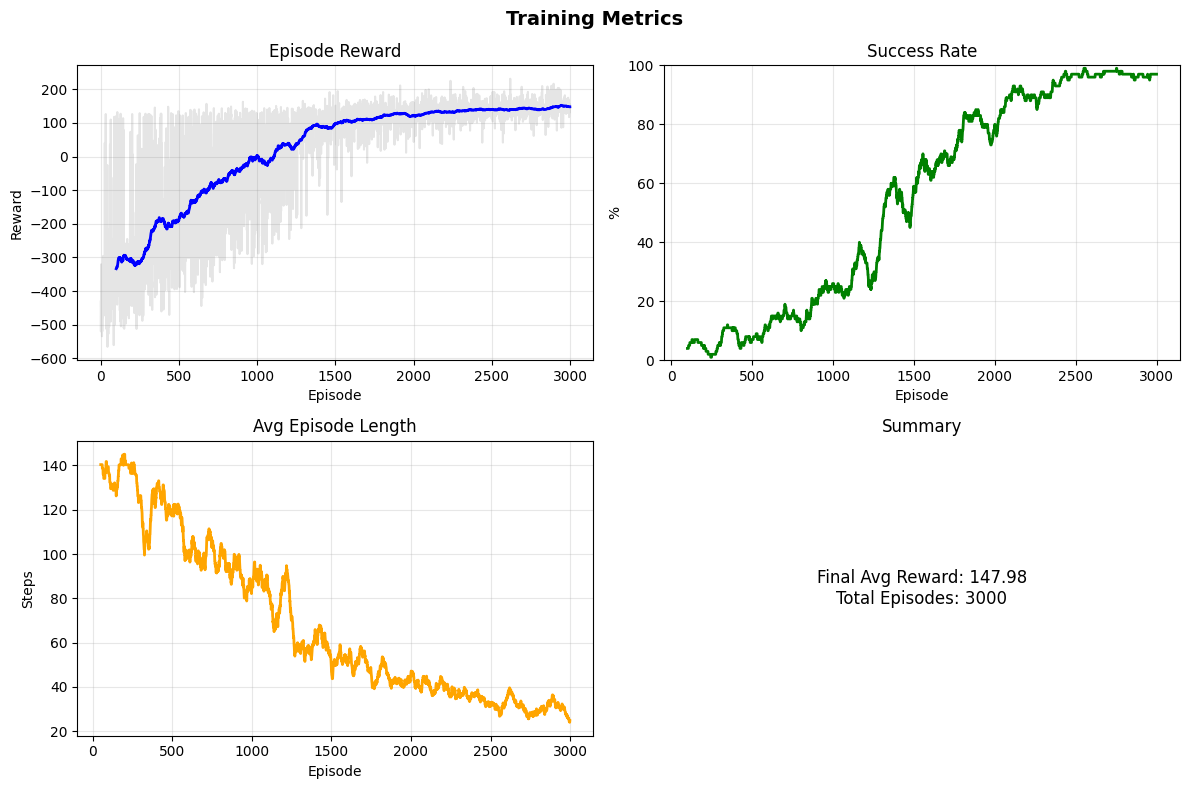

In [9]:
plot_results(history, save_path='training_results.png')

In [10]:
test_agent(start_pos=(1, 7), angle=0, delay=0.12)

Test finished. Reward: 127.5, Steps: 16


[(1, 7),
 (2, 7),
 (3, 7),
 (4, 7),
 (5, 7),
 (5, 7),
 (5, 6),
 (5, 5),
 (5, 5),
 (6, 5),
 (7, 5),
 (8, 5),
 (8, 5),
 (8, 6),
 (8, 7),
 (8, 7),
 (7, 7)]

In [11]:
test_agent(start_pos=(3, 3), angle=1, delay=0.12)

Test finished. Reward: 127.5, Steps: 25


[(3, 3),
 (3, 3),
 (4, 3),
 (5, 3),
 (5, 3),
 (5, 2),
 (5, 1),
 (5, 1),
 (6, 1),
 (7, 1),
 (8, 1),
 (8, 1),
 (8, 2),
 (8, 3),
 (8, 3),
 (7, 3),
 (7, 3),
 (7, 4),
 (7, 5),
 (7, 5),
 (8, 5),
 (8, 5),
 (8, 6),
 (8, 7),
 (8, 7),
 (7, 7)]